<a href="https://colab.research.google.com/github/grasht/grashaw_GAN_research_project/blob/main/HW4_pt3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3
**Part 1:**
I chose BERT embeddings for their ability to understand bidirectional context. This bidirectional learning of words seems like a powerful tool. Further, I do not see myself working with Fast Text because I do not have the need to work with morphologically rich languages. Word2Vec and Glove would have been fine choices too. The former provides nice simplicity while being a self supervised architecture that is quick to train. The latter provides global contextualization from its term-cooccurance matrices that also seem like a powerful ability, but ultimately BERT embeddings won out for providing a way to learn different meanings of the same word, something that I assume to be a very complicated, but important part of language.


**Sources:**

CodeEmporium - https://www.youtube.com/watch?v=EcuVZzUiHMY


Medium - https://medium.com/@davidlfliang/intro-getting-started-with-text-embeddings-using-bert-9f8c3b98dee6


In [ ]:
%pip install transformers torch


In [ ]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

text = input("Enter two words: ")
assert len(text.split()) == 2, "Input must be two words separated by white space."

inputs = tokenizer(text, return_tensors='pt')

with torch.no_grad():
  outputs = model(**inputs)

last_hidden_states = outputs.last_hidden_state

# Print embeddings for each token along with their vector dimension
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
print(f"\nTokens as generated by BERT: {tokens}")

embedding_dict = {}
prev_token = ''
for token, embedding in zip(tokens, last_hidden_states[0]):
  if token == '[CLS]' or token == '[SEP]':
    continue
  if token.startswith('##'):
    new_token = prev_token + token[2:]
    embedding_dict[new_token] = embedding_dict.pop(prev_token)
    embedding_dict[new_token].append(embedding.detach())
    prev_token = new_token

  else:
    prev_token = token
    embedding_dict[token] = [embedding.detach()]

print("\nFinal Embeddings: ")
for token, embedding in embedding_dict.items():
  if token == 'UNK':
    print("Warning: One of the given words is out of vocabulary. Try changing the spelling or form.")
  mean_embedding = torch.stack(embedding, dim=0).mean(dim=0)
  print(f"Token: {token}, Embedding Dimension: {mean_embedding.shape}.\nEmbedding: {mean_embedding}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
tokenizer_config.json: 100%
 48.0/48.0 [00:00<00:00, 6.13kB/s]
vocab.txt:
 232k/? [00:00<00:00, 6.90MB/s]
tokenizer.json:
 466k/? [00:00<00:00, 24.1MB/s]
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
WARNING:huggingface_hub.utils._http:Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
config.json: 100%
 570/570 [00:00<00:00, 75.7kB/s]
model.safetensors: 100%
 440M/440M [00:01<00:00, 607MB/s]
Loading weights: 100%
 199/199 [00:00<00:00, 916.00it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  |
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  |
cls.seq_relationship.bias                  | UNEXPECTED |  |
cls.predictions.transform.dense.weight     | UNEXPECTED |  |
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  |
cls.predictions.bias                       | UNEXPECTED |  |
cls.predictions.transform.dense.bias       | UNEXPECTED |  |
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  |

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Enter two words: cat lion

Tokens as generated by BERT: ['[CLS]', 'cat', 'lion', '[SEP]']

Final Embeddings:
Token: cat, Embedding Dimension: torch.Size([768]).
Embedding: tensor([-4.1682e-01, -3.3284e-01,  1.2710e-01, -5.4429e-01,  2.5290e-01,
         5.2117e-01,  7.1034e-01,  4.4963e-01, -4.8828e-01, -2.4858e-01,
        -1.2352e-01, -5.0233e-01, -4.4920e-01,  6.1628e-02, -3.8355e-01,
        -7.2460e-02, -2.1463e-03,  4.8944e-01, -3.2089e-01,  3.5738e-01,
        -3.1278e-01, -5.5321e-01, -6.0109e-01,  2.2795e-01, -6.4234e-02,
         2.8650e-01, -1.4199e-02,  7.4404e-01, -1.6265e-01, -1.7625e-01,
        -1.5622e-01, -4.6780e-01,  1.9802e-01,  1.8991e-01, -2.2192e-01,
        -3.2081e-01, -5.9577e-01,  4.9408e-01, -3.7149e-01,  1.3333e-01,
         6.0524e-01,  1.6556e-01,  1.3086e-01,  2.5166e-01,  4.7487e-01,
        -1.1666e-01,  1.1710e-01, -9.2678e-02,  4.5064e-01, -5.6858e-01,
        -1.0938e-01,  3.8257e-01, -6.6397e-01,  2.4089e-01, -2.5546e-01,
         3.2551e-01,  1.2604e-01, -1.8845e-01,  1.2461e-01, -6.1943e-02,
        -4.5679e-01, -2.5784e-01,  7.1085e-01,  8.5173e-02, -3.9785e-01,
         5.8496e-01,  2.5530e-01,  9.8245e-02, -4.2389e-01,  1.6966e-01,
        -1.9097e-01, -1.6733e-02, -1.8457e-01,  5.0979e-01, -4.1535e-01,
         6.0925e-03,  1.8084e-01, -1.5317e-01, -1.3811e-01, -3.4244e-01,
         1.0451e+00,  5.0467e-01, -3.6952e-01,  1.5908e-01,  1.1736e-01,
         3.8663e-01, -1.5629e-01, -3.8758e-01, -3.5832e-01,  5.3333e-01,
        -1.2504e-01, -1.7588e-01, -4.9073e-01,  2.4119e-01, -2.2409e-01,
        -1.5590e-01, -2.0747e-01, -9.6574e-02,  6.3327e-01, -5.2241e-01,
        -8.7241e-02, -2.6794e-01, -6.5328e-01,  2.9071e-01, -4.6541e-01,
        -3.4295e-01, -4.8190e-01, -8.4267e-03, -3.8694e-01,  3.5092e-01,
        -1.4676e-01, -2.5752e-01,  3.7505e-01, -1.0878e-02, -2.7517e-01,
         7.3925e-01, -1.3644e-01, -2.0033e-01, -1.4249e-01,  8.3643e-02,
         3.0644e-01,  5.6612e-01,  6.3873e-02,  7.4121e-01,  2.0265e-01,
        -4.7252e-02,  1.9996e-01,  5.6904e-01,  2.8569e-01, -3.7883e-01,
         6.9248e-01,  6.1619e-01, -3.1364e-02, -5.1494e-01,  1.6299e-01,
         2.9638e-01,  3.7081e-01, -4.0491e-02,  1.8729e-01, -5.3374e-02,
         1.3252e-01, -9.8632e-02,  1.9131e-01,  1.5628e-02,  2.6459e-01,
         4.8588e-01,  1.0179e-01,  8.7593e-02, -2.4597e-01,  4.9628e-03,
        -2.3650e-01, -8.0983e-02, -3.3389e-01, -3.3896e-01, -1.5705e-01,
         2.8716e-01, -8.9768e-02, -1.6925e-01, -8.4468e-03,  2.2132e-01,
         7.7407e-01, -3.1341e-01,  2.5846e-01, -6.4784e-01, -7.0287e-01,
         1.2580e-01, -4.5482e-01,  2.3068e-01, -9.8171e-01, -8.4731e-02,
        -5.4236e-01, -8.9115e-02,  5.3539e-01,  6.3574e-03, -1.1760e-01,
        -2.4142e-01, -4.1962e-01, -4.9744e-02, -1.3445e-02,  1.3339e-01,
        -4.2742e-01,  9.9907e-01, -2.2297e-01,  2.0492e-02,  1.7849e-01,
         1.9523e-01,  1.3891e+00, -4.2137e-01,  9.0645e-01, -3.0906e-02,
         1.0726e-01, -4.0611e-01, -7.8484e-01,  3.7280e-01,  9.7522e-01,
        -8.1320e-01, -1.1572e-01, -5.0555e-01,  8.0273e-02,  2.5819e-01,
        -3.9178e-02, -4.7842e-01,  3.4888e-01,  5.6914e-02, -1.6227e-02,
         7.3372e-01,  9.1154e-02,  6.7372e-02,  1.4823e-01,  1.3431e-01,
        -2.2803e-01,  3.4072e-01,  4.2788e-01, -1.9813e-01,  4.1325e-01,
         1.1171e-01,  2.9739e-01, -1.6295e-01,  9.4158e-02, -1.7947e-01,
         7.6490e-01, -4.5084e-02, -6.2779e-01,  1.1110e+00, -4.3445e-01,
         8.1246e-01,  2.7645e-01, -8.3977e-02,  7.3441e-01,  3.4037e-01,
         6.9554e-02, -4.3958e-02,  5.5717e-02,  4.3207e-01,  2.2379e-01,
        -2.6322e-01, -3.3352e-01,  1.6156e-01,  5.1479e-03,  2.9002e-01,
         1.6991e-01,  8.5126e-01,  5.9087e-01, -6.1906e-02, -2.2313e-01,
        -3.2528e-01, -2.2944e-02,  2.1916e-01,  1.0498e-01, -2.0716e-01,
         2.4314e-01, -7.8970e-01, -2.5646e-01, -3.4958e-01, -3.1178e-01,
        -2.4499e-01, -2.4637e-01, -1.1796e-02, -5.0047e-01,  3.4667e-01,
        -4.2311e-01,  5.4885e-02,  9.8851e-01, -5.9049e-01, -2.8176e-01,
        -3.8813e-01, -1.5737e-01,  1.0932e-01, -4.2663e-02, -4.0006e-01,
        -1.1858e-03, -1.4057e-01, -7.1518e-02,  2.0771e-01,  3.9666e-01,
        -1.9267e-01,  4.4386e-01, -1.4238e-01,  3.4242e-01, -3.1458e-01,
        -1.7593e-01,  5.0245e-01,  3.3438e-01, -3.1552e-01,  1.9995e-01,
        -8.4267e-01,  1.3562e-01, -1.7271e-01, -1.0733e-01, -3.5961e-01,
         1.6481e-01,  5.3216e-01, -7.2779e-02, -3.4376e-01, -3.0597e-01,
        -2.0557e-01, -1.9793e-01,  7.1275e-01,  3.4947e-01, -4.7958e-01,
         4.7334e-01,  4.8411e-01,  1.1313e-01,  1.6795e-02,  6.3590e-01,
        -6.2330e-02, -6.9292e-01, -2.0903e-02, -5.7553e+00,  6.1419e-03,
        -2.9797e-02, -2.5841e-01,  4.2074e-01, -5.9675e-01,  1.0754e-01,
        -3.7288e-01, -3.4348e-01, -5.7553e-02,  1.5252e-01, -1.8442e-01,
         3.6566e-01, -1.1721e-02,  2.4317e-02, -5.6999e-01, -6.4648e-01,
        -6.3000e-02,  2.0574e-02,  1.2139e+00, -3.5318e-02, -5.5553e-01,
        -2.7526e-01, -2.3627e-01,  5.6048e-02,  7.0009e-01, -1.0118e+00,
        -9.7397e-02, -1.0144e-01,  7.7535e-01, -1.9458e-01, -1.7630e-03,
        -3.4227e-01, -2.7070e-02,  2.7497e-01, -7.8294e-02,  5.0271e-01,
         8.0074e-02,  5.4658e-01,  3.0414e-02,  5.3794e-01, -3.6813e-01,
         3.7381e-01,  1.2469e+00, -9.2565e-02,  1.7225e-01, -3.9031e-01,
        -4.0396e-01, -3.1435e-01,  6.3158e-01, -2.5515e-01, -8.1053e-02,
         1.2017e-02,  4.9475e-02,  5.3538e-01, -9.6045e-02,  2.0831e-01,
         2.7848e-01, -8.2673e-01, -2.6694e-02,  1.1171e-01, -2.5537e-01,
        -9.2994e-02,  1.6308e-01,  4.4877e-01, -1.7127e-01, -3.9936e-01,
        -1.8488e+00,  7.6538e-01, -1.9656e-01, -2.6703e-01, -4.8460e-01,
        -3.8404e-01, -1.3391e+00,  2.0562e-01, -5.5770e-02,  3.6489e-01,
         1.5292e-02, -8.5165e-02, -5.5079e-01, -6.3864e-02, -3.8756e-02,
         1.2554e-01,  2.6761e-01, -6.5441e-01, -7.2107e-01,  1.3297e-01,
         2.0488e-01, -6.8543e-01,  2.6660e-01,  4.0059e-01, -7.0050e-01,
         2.4622e-01,  1.1382e-01,  1.4552e-01,  3.2413e-01,  7.7629e-02,
        -3.8792e-01,  5.5043e-01,  1.3515e-02,  2.1766e-01, -3.8238e-01,
         3.3330e-01, -5.6608e-01,  3.9188e-01,  2.5615e-01,  8.9111e-02,
         2.2989e-01,  3.1468e-01,  8.2628e-02, -2.9824e-02, -4.2637e-01,
         9.9837e-02, -4.8128e-01,  1.0188e-01,  3.0956e-01,  8.1968e-01,
         1.8340e-01, -4.8385e-04,  3.1347e-01, -2.1480e-01, -2.6673e-01,
        -1.0587e-01, -3.8739e-01,  2.8774e-01,  2.9046e-01,  1.2877e-01,
         1.3088e-01, -1.5790e-01,  3.8570e-03,  3.1796e-01, -2.9072e-01,
         3.0709e-01,  1.0877e-01,  4.4864e-01,  1.4592e-02, -4.7364e-01,
        -6.6574e-01, -1.2836e-01, -1.5525e-01, -2.8626e-01,  1.3290e-01,
        -3.6067e-01,  5.9099e-01, -4.1944e-01,  2.3121e-01,  4.5201e-01,
        -9.5937e-02,  4.5655e-01,  4.8660e-01, -2.5722e-01, -4.6429e-01,
         9.5303e-02,  3.8901e-01, -6.2282e-01, -1.3945e+00,  4.9614e-01,
         4.5679e-02, -4.4754e-01,  4.4571e-01, -5.9610e-01, -2.3608e-01,
        -9.2960e-01, -1.2540e-01,  4.5502e-01,  3.3390e-01,  8.0673e-01,
         1.2172e-01, -1.0551e-01,  3.8095e-01,  2.2110e-01,  6.2738e-02,
         1.0362e-01,  2.0133e-01, -6.0956e-01,  1.5390e-01, -1.6541e-01,
         1.4310e-01, -2.3699e-01,  7.3432e-01, -7.4671e-02, -3.8294e-02,
        -4.3944e-01,  2.3052e-01,  1.2459e-01, -1.2063e-01, -4.8083e-02,
        -5.0120e-01,  1.2821e-01,  4.4930e-01, -1.0404e+00,  6.3446e-01,
        -1.1733e-01, -2.5288e-01, -7.2336e-01,  4.0997e-01,  3.3027e-01,
         1.0147e+00,  5.8184e-01,  5.3017e-01, -3.0291e-01,  2.6883e-01,
         2.7090e-01,  4.0593e-02,  3.7867e-01,  1.2443e-02,  7.7997e-01,
         3.4325e-01, -2.9744e-01,  9.1194e-02, -1.2915e-01, -3.9812e-03,
         7.8602e-02, -2.4593e-01,  1.6501e-01,  4.7169e-01, -2.3372e-01,
         5.0516e-01, -2.2906e-01,  3.0286e-01,  2.6212e-01, -1.0034e-01,
        -5.4863e-01, -2.5369e-01, -3.8725e-01,  6.8440e-01,  1.2468e-01,
        -1.1831e-01,  1.7715e-01, -1.3747e-01,  2.3098e-01, -3.9469e-02,
         7.0078e-01,  7.5774e-02,  6.8283e-01, -4.2487e-03, -7.5988e-01,
        -1.6535e-01,  2.7037e-01, -2.0457e-02,  5.3240e-01,  1.4391e-01,
         5.6251e-01, -5.5555e-01, -8.6561e-02,  3.2211e-01, -2.9725e-01,
        -2.4359e-01,  2.2682e-01,  1.4227e-01,  2.6095e-01,  3.4704e-01,
         5.5151e-01, -2.7606e-01,  2.7554e-01,  1.3997e-01, -6.2288e-01,
         3.2071e-01,  3.3093e-01,  5.3846e-01,  1.5343e-01,  4.3027e-01,
        -7.0932e-01,  3.4848e-01, -4.5639e-01,  1.8655e-01, -1.7313e-01,
        -6.6110e-02, -2.2737e-03,  5.1505e-01, -3.0527e-01, -3.1356e-01,
         9.8652e-01, -3.1976e-01,  7.2748e-02, -7.4510e-02, -2.5188e-01,
        -5.0170e-01, -1.3587e-01,  2.7042e-01,  2.8699e-01,  4.8635e-01,
        -2.6736e-01,  1.2938e-01,  2.7026e-01,  1.5372e-01, -1.7986e-01,
        -6.4777e-02, -1.3318e-01, -1.2852e-02,  1.8045e-01,  2.6223e-01,
        -4.7367e-01, -1.1667e-01, -6.5825e-01,  4.5033e-01,  2.1760e-01,
         1.6539e-01, -2.0469e-01, -4.0438e-02, -6.7233e-01,  2.2698e-01,
        -3.6104e-01, -7.5958e-02,  2.6987e-02,  2.0845e-01,  9.9685e-03,
        -3.4296e-01, -1.6892e-01, -8.5664e-02, -2.1846e-01, -6.0481e-01,
        -7.2001e-03, -1.6728e-01,  6.1915e-03,  7.9497e-02, -2.9731e-01,
        -2.3958e-01,  3.7335e-01,  3.4222e-01, -3.2216e-01, -3.2207e-01,
         3.5514e-01,  1.5044e-01,  1.5353e-01,  1.7783e-01, -7.3547e-01,
         2.5923e-01,  2.4283e-01, -6.3316e-01,  3.4238e-01,  5.5590e-02,
         6.0168e-02, -9.3568e-02, -1.2979e-01, -5.1591e-01,  6.5357e-02,
         2.9325e-02, -2.8515e-01, -2.2264e-01,  2.5095e-01,  2.7314e-01,
        -8.8864e-01,  2.7301e-01, -1.5712e-01, -3.3009e-01, -1.7949e-01,
        -1.7130e-02, -8.7238e-02,  2.5742e-01,  5.7957e-02,  1.4281e-02,
         4.3558e-02, -5.0327e-01,  3.1565e-01,  6.8328e-02,  6.1270e-01,
         3.7689e-01, -1.6631e-01,  2.8485e-02, -3.2876e-02,  3.0667e-01,
        -5.0624e-02, -2.8821e-01, -3.9260e-01,  8.4579e-01, -8.4327e-02,
        -4.0991e-01, -1.3504e-01, -6.5325e-01,  3.5565e-01, -9.1879e-02,
        -9.5616e-02,  2.2831e-02,  6.7102e-01,  3.4837e-01,  1.9197e-01,
        -1.0437e-01,  1.6106e-01,  4.0714e-01, -1.1430e-01, -3.1747e-01,
        -5.6581e-02, -7.9996e-01,  4.2341e-01, -1.2939e-01, -3.1883e-01,
        -3.6704e-02, -1.6372e-01, -9.4584e-02,  7.0571e-02,  5.1913e-01,
         1.8496e-01, -6.0052e-01, -2.3475e-02, -5.6221e-01,  1.4792e-01,
        -2.6339e-02, -2.9850e-01, -1.0326e-01,  6.2471e-01, -2.1317e-01,
         2.1578e-01,  1.4271e-01,  5.0436e-01, -5.8156e-01, -4.1384e-01,
         2.1046e-01,  1.2762e-01, -6.0065e-01, -3.5050e-01,  3.5594e-01,
        -2.7848e-01, -2.8182e-02, -1.2371e-01, -1.6013e-01,  3.3932e-01,
        -2.4374e-01, -3.0364e-01, -4.2341e-01,  4.0201e-01, -7.0422e-01,
         3.1441e-02,  2.3696e-01, -2.9078e-01, -8.2015e-01, -4.7382e-02,
         2.2897e-01, -5.1578e-02, -2.1988e-01, -3.0681e-01,  2.4737e-01,
        -2.1364e-01, -3.7875e-01, -3.8036e-01, -5.4822e-01,  1.7980e-01,
        -1.4670e-01, -1.8782e-01, -5.7143e-01,  5.9902e-01,  3.9018e-01,
         5.5438e-01,  2.9470e-01,  2.7409e-04, -7.2186e-01, -8.4865e-02,
        -5.4614e-01,  5.2519e-01, -3.1979e-01,  9.4272e-01, -2.4455e-01,
        -4.0431e-01, -1.8534e-01,  2.1272e-01, -2.7572e-01, -2.6168e-01,
        -3.6298e-01,  6.1281e-01, -3.2577e-01])...
Token: lion, Embedding Dimension: torch.Size([768]).
Embedding: tensor([-3.8593e-01, -3.7921e-01, -1.1517e+00, -1.8196e-01,  1.8985e-01,
         2.5382e-01,  2.5578e-01,  5.1309e-01, -6.6044e-01, -1.0466e-01,
        -2.7822e-02,  2.6239e-01,  2.2274e-01,  2.8939e-02, -7.9811e-01,
        -8.4091e-01,  2.0245e-03,  9.0841e-02,  1.4986e-01,  2.5930e-01,
        -8.1492e-02, -9.0714e-02, -2.1723e-01, -2.2682e-01,  5.5312e-02,
         3.1746e-01, -2.4669e-01, -1.1244e-01, -4.4649e-02,  8.5010e-01,
        -1.5723e-01, -1.2601e-01, -1.8981e-02,  4.3419e-01, -3.9445e-01,
        -9.6005e-01, -3.0737e-01,  1.9804e-01, -3.1465e-01,  2.1438e-01,
         2.2637e-01, -8.1484e-02,  5.8417e-02, -2.6478e-01, -1.0896e-01,
        -1.6489e-01,  4.6212e-01,  5.5889e-01, -1.7071e-01, -7.0788e-02,
        -7.4546e-01, -1.2275e-02, -2.8182e-01, -2.5163e-03,  1.5087e-01,
        -5.9918e-01,  4.3341e-01,  2.2956e-01, -4.8019e-01, -6.8472e-01,
         4.4505e-01, -5.6165e-01,  5.3144e-01,  2.2358e-01, -1.9375e-02,
         3.7454e-01,  1.3392e+00,  5.6573e-01, -3.3765e-01,  6.0091e-01,
        -2.9429e-01,  5.9621e-01, -2.0277e-01, -4.7549e-01,  3.9462e-01,
        -4.1752e-01,  3.9872e-02,  3.2638e-02,  4.7887e-01, -2.9436e-03,
         1.5972e-01,  5.3749e-01,  7.8372e-02, -1.8708e-01, -3.3919e-03,
        -5.4278e-01, -4.2960e-01, -5.2127e-01, -3.7220e-01,  8.3497e-01,
        -3.7473e-01,  1.2107e-02, -7.5004e-02,  4.1199e-01, -8.1015e-02,
         2.0672e-01, -4.1777e-03,  2.9913e-01,  2.6372e-01, -1.1913e+00,
        -5.6485e-01, -7.1362e-01, -1.7421e-01,  4.0666e-01, -6.4847e-01,
         1.1202e-02, -4.7843e-01, -2.9119e-01, -1.0266e-01,  3.2553e-01,
         1.3100e-01, -6.5034e-01,  5.5238e-01,  1.4309e-01, -2.6768e-01,
         8.0708e-01,  1.0782e-01, -1.5799e-01,  5.9178e-02,  1.4948e-01,
        -2.1771e-01, -2.6204e-01, -4.1852e-01,  5.7645e-01,  5.0450e-01,
         2.4055e-02, -1.0124e+00, -5.9412e-01, -8.1036e-02, -6.2353e-01,
         4.5121e-01,  5.1597e-01, -2.6655e-01,  5.7017e-01, -4.6545e-01,
        -2.1828e-01, -1.3133e-01, -9.9989e-02,  3.2234e-01, -9.9608e-01,
         2.3943e-01,  4.5881e-01,  2.8627e-01,  3.5383e-01,  4.0231e-01,
         8.5419e-02, -3.0726e-02,  7.2259e-02, -4.6897e-01,  3.0877e-01,
        -3.9126e-01,  6.3808e-01, -3.6201e-02, -5.8502e-01,  7.0455e-02,
         3.4932e-01,  8.6077e-02,  3.2169e-01,  1.2524e-01,  3.0243e-01,
         6.4295e-01,  4.6300e-01, -3.6212e-01,  2.8562e-01, -4.9805e-01,
        -4.1791e-01,  2.4730e-01,  1.1736e+00, -4.5513e-01, -6.3640e-01,
        -3.4930e-01,  6.8434e-02,  9.8007e-01,  5.1314e-01, -2.4568e-01,
         3.0373e-01, -1.4995e-01,  1.5791e-01,  1.1062e-01,  3.9728e-01,
        -4.3676e-01,  1.6714e-01,  5.5693e-02,  8.9060e-02,  4.5257e-01,
        -1.4629e-01,  1.7968e-01, -7.7510e-01,  5.8404e-01, -4.0334e-01,
        -1.0832e+00, -4.3314e-01, -1.1993e-01,  8.2298e-02,  5.0755e-01,
        -5.3314e-01, -1.4131e-01, -5.1995e-01,  6.3779e-01, -2.4218e-01,
         4.2798e-01, -7.0876e-01,  5.9560e-01,  5.6631e-01,  1.6604e-01,
         3.6550e-01,  1.8498e-01, -1.6308e-01,  3.6139e-01, -1.4968e-01,
        -6.4347e-01,  8.6772e-01,  1.3995e-01,  3.5316e-01,  1.0497e+00,
         2.1310e-02,  1.4215e-01, -4.3633e-01, -6.2805e-01,  6.7259e-02,
         9.4924e-01, -2.8808e-01, -7.6512e-01,  2.9630e-01, -7.6077e-01,
         3.0319e-01,  4.9808e-01, -3.6983e-01,  2.6345e-01, -1.2872e-01,
         9.1330e-02, -2.7716e-01, -6.0464e-02, -2.7642e-01, -1.1320e+00,
         5.7936e-01,  7.7005e-01, -2.3431e-01,  2.4402e-01, -3.4945e-01,
        -3.2492e-01,  4.9845e-01,  6.9659e-01,  8.5217e-02,  4.3611e-02,
         4.0541e-02,  9.2344e-01, -5.4422e-02,  4.3808e-01, -3.0281e-02,
         8.6318e-01, -5.5252e-01,  2.9556e-01,  3.8112e-01, -2.7776e-01,
        -8.3244e-01, -3.4907e-01, -7.0942e-01,  5.7727e-01,  6.8793e-01,
        -2.3325e-02,  1.5009e-01,  9.6212e-01, -5.1762e-01,  2.9694e-02,
         6.2913e-02,  2.0367e-01, -2.4583e-01,  3.4553e-01, -3.3906e-01,
        -8.3991e-02, -7.8778e-02, -1.9747e-01,  2.1075e-01,  1.9421e-01,
         4.7847e-01,  1.9293e-01,  2.4331e-01,  6.2003e-01, -7.4926e-01,
         2.9135e-01, -8.7895e-02, -3.3436e-01, -4.1754e-01,  4.1153e-01,
        -5.2663e-01, -1.5524e-01, -1.0256e+00, -7.0272e-03, -1.9081e-01,
        -4.7983e-01,  8.0862e-01,  3.9508e-01,  2.8134e-01,  3.2170e-02,
        -4.5018e-02, -3.0988e-01,  7.3626e-01,  2.4986e-01, -4.4321e-01,
         7.7590e-02,  3.4660e-01,  3.0151e-01, -6.4904e-02,  8.3182e-01,
        -1.7878e-02, -4.3386e-01,  4.8855e-01, -5.0685e+00, -6.3197e-01,
        -4.8392e-01, -4.1901e-01,  2.6365e-01, -3.3200e-01, -5.0173e-01,
        -4.3306e-01, -6.7218e-01,  2.8912e-01,  5.1204e-01,  1.3312e-01,
         1.6465e-01,  3.1069e-01,  3.6195e-01, -6.3144e-01, -1.5048e-01,
        -7.2628e-01, -6.2435e-01,  1.0440e+00,  3.5281e-02, -5.3359e-01,
         5.0994e-01, -3.0302e-01, -1.6974e-01,  5.2787e-01,  1.7562e-01,
         9.8222e-02, -6.6463e-01, -4.0053e-01, -5.1151e-02,  4.7614e-02,
        -2.1356e-01,  2.7072e-01,  4.5256e-01,  1.6856e-01, -3.1992e-01,
        -4.1095e-01,  1.4353e+00,  6.0832e-01,  8.5807e-01, -2.4298e-01,
         1.7589e-01,  1.1314e+00,  4.2273e-02, -2.2124e-01,  4.4504e-01,
        -5.0261e-01, -3.7603e-02,  1.2341e-01,  6.3400e-01, -3.8855e-01,
        -3.6902e-01, -7.8855e-01,  4.8542e-01,  2.2930e-01, -7.7783e-02,
         2.1268e-01, -3.6552e-01, -2.7875e-01,  2.9246e-01, -1.0602e-01,
        -2.5525e-01,  4.2747e-01, -8.6229e-01, -9.6823e-02,  1.8565e-01,
        -1.3698e+00,  3.8667e-01,  2.8389e-01,  7.9224e-02, -6.8950e-02,
         4.9927e-02, -1.3365e+00, -5.7078e-01,  5.5923e-01, -7.3204e-01,
        -3.2168e-01, -4.0288e-01, -6.5498e-01,  5.2914e-01,  2.4216e-01,
         2.4976e-01,  7.6723e-02, -2.8651e-01, -5.0362e-01,  7.2496e-01,
        -5.0280e-01, -2.3151e-01, -1.3967e-01,  2.9539e-01, -2.9272e-01,
         2.8096e-01,  3.8343e-01,  8.5688e-01, -4.1017e-02,  9.7429e-02,
        -5.0873e-01, -2.9650e-01,  2.2217e-01, -6.1496e-01, -5.3317e-01,
        -2.8469e-01, -3.0779e-01,  1.3941e-01, -3.8909e-01, -7.1888e-01,
         3.5558e-01,  5.0394e-01,  2.0895e-01, -8.3478e-02,  4.0342e-03,
         7.1714e-01,  1.4781e-01, -6.5501e-01,  1.0634e-01,  3.0245e-01,
         5.3146e-01,  3.2456e-01,  5.1323e-01, -7.0398e-01,  2.8284e-01,
        -3.1243e-01,  1.8758e-01,  4.1353e-01, -6.6088e-02, -3.5528e-01,
        -7.5718e-01, -3.0874e-01, -2.7022e-02, -2.5893e-01,  4.8568e-01,
         8.8034e-03, -3.4915e-01,  3.5363e-01, -3.3570e-01,  1.0498e-01,
        -6.0049e-01, -2.1596e-01,  7.9929e-01,  2.3781e-01, -1.4685e-01,
        -1.3511e-01,  2.7476e-01, -5.2356e-01,  3.0110e-01,  3.2749e-01,
         2.5706e-01,  5.6792e-01,  6.9012e-01,  6.0319e-01, -7.7249e-01,
        -2.4101e-01,  9.8307e-02, -3.4879e-01, -7.1186e-01, -1.3635e-01,
        -7.3873e-01, -3.0952e-01, -3.9519e-01,  1.2315e-01, -2.1794e-01,
         8.1089e-01,  5.3051e-01, -5.2914e-02,  9.1029e-01,  5.3702e-01,
         1.2931e-01, -8.2333e-01,  3.4294e-01,  4.4330e-01, -7.0791e-01,
        -5.4188e-01,  9.1701e-01, -1.8811e-01, -4.1566e-02, -1.0295e-02,
        -2.7973e-01, -4.6413e-02,  7.8331e-01, -1.2336e-01, -3.2610e-01,
         3.5508e-02, -2.5975e-01,  1.1953e+00,  2.9326e-01, -7.7479e-01,
        -2.3495e-01,  5.6331e-01,  8.0699e-01,  3.2073e-01, -3.2890e-01,
         1.7443e-02,  2.0861e-01, -4.4039e-01,  3.9096e-02, -2.0975e-02,
         2.4834e-01,  5.8286e-01, -2.0719e-01, -5.2505e-01, -9.0402e-01,
         1.3319e-02, -2.2229e-01,  1.7908e-01,  6.9099e-01,  1.0777e-01,
         2.1030e-01, -4.0440e-01, -4.2147e-01,  4.0499e-01, -1.1641e-01,
        -6.8615e-01, -4.1076e-01, -3.6233e-01,  1.0774e+00,  1.3760e-01,
         3.6512e-01,  7.6242e-02, -1.0474e-01, -8.2032e-01, -9.2306e-01,
        -2.9937e-01, -2.6502e-01,  3.3014e-01,  5.8103e-01, -6.9442e-02,
        -2.8887e-01,  6.8854e-01, -2.0010e-02,  7.0028e-01,  5.6113e-01,
         2.3771e-01, -3.7465e-01,  5.1650e-01,  5.2880e-01, -3.6253e-01,
        -2.3057e-01, -3.8812e-02, -5.7394e-01,  5.5203e-01, -5.4005e-01,
        -4.8762e-01,  1.4530e-01,  1.6291e-03,  2.8920e-01, -5.7627e-02,
        -8.4774e-03,  9.5771e-01,  5.2691e-01, -2.7874e-01,  6.7329e-01,
         2.9391e-02, -4.9727e-01,  1.2582e-01, -9.8326e-01, -3.2898e-01,
        -1.2199e-01,  2.2419e-01,  3.1958e-01, -3.6591e-01,  1.0735e+00,
        -7.5547e-01,  5.9953e-01, -3.1044e-01, -1.2756e-01, -3.2866e-01,
        -8.4610e-02,  7.3705e-01,  6.5181e-01, -1.7756e-01, -6.7293e-01,
         3.9058e-01,  5.9553e-01, -6.1404e-01, -2.4423e-01,  2.0514e-01,
        -1.3540e+00, -3.5500e-01, -3.7064e-01,  1.7867e-02,  7.0677e-01,
         5.6531e-01,  3.0887e-01,  5.8287e-01, -4.8826e-01, -2.7208e-01,
        -4.1048e-01, -5.4646e-01, -6.1024e-01,  2.4654e-01,  4.7755e-02,
         2.6813e-01,  7.1301e-01, -2.0094e-01,  3.1916e-01, -9.2984e-01,
         2.1563e-01, -7.0172e-01,  3.0640e-01, -3.0813e-01,  2.5014e-01,
         2.9520e-01, -3.4571e-01, -2.8055e-01,  1.9905e-01, -2.8176e-01,
        -3.4406e-01, -1.2284e-01, -2.0226e-01, -5.8522e-01, -2.5476e-01,
        -6.7346e-02,  7.4223e-01, -8.2269e-01,  5.7006e-01,  4.5995e-01,
        -7.0142e-01,  8.0342e-02,  2.1924e-01, -9.1013e-02, -5.7120e-01,
         5.8529e-01,  2.2221e-01,  3.1542e-01,  4.7805e-01, -8.6131e-01,
         3.4104e-01,  2.1609e-01,  7.3544e-01,  2.7517e-01, -6.5451e-01,
         1.8040e-01, -1.5476e-01,  9.0107e-01, -5.1248e-01,  1.1081e+00,
        -2.1098e-02, -5.6808e-01, -5.5645e-01,  8.5044e-02,  1.9793e-01,
        -3.7503e-01, -9.0935e-02,  1.1630e-01, -2.4995e-01,  2.7511e-02,
        -2.0643e-01,  1.7904e-01,  1.1481e+00, -5.5396e-01, -3.4494e-01,
        -1.6343e-01, -4.1954e-01,  2.1683e-01,  1.7011e-01, -9.0170e-02,
        -1.2117e-01, -4.5693e-01,  3.2964e-01,  2.7470e-01,  5.2327e-01,
         3.8842e-01, -2.1345e-01, -4.5383e-01,  5.7223e-01, -5.3714e-01,
        -5.8075e-01, -2.3635e-01, -2.0942e-01,  6.1029e-02, -2.8602e-02,
         8.7340e-01,  2.4889e-01,  3.5576e-01,  8.0230e-02,  7.8500e-02,
         3.3754e-01, -1.1614e+00, -5.4991e-01, -4.0335e-01,  2.2916e-03,
        -4.6923e-01, -5.9037e-01,  1.3738e+00,  2.1608e-01,  1.9873e-01,
        -4.1302e-01,  3.0514e-01, -2.8263e-01,  2.0226e-01,  2.2808e-01,
         1.0315e-01, -3.0117e-01,  4.9687e-01, -7.0362e-02, -4.6679e-02,
        -7.3118e-02, -4.2323e-02,  9.5148e-01,  9.9786e-01, -3.8174e-01,
         3.7828e-01, -1.2314e-01, -1.5789e-01, -4.4388e-01,  4.1478e-01,
        -3.9802e-01, -5.0739e-01, -5.7979e-02,  2.3341e-01,  4.3465e-02,
        -2.6113e-01,  2.5056e-01, -3.7869e-02, -2.4396e-01, -3.9773e-03,
         4.1944e-01,  1.3491e-01, -2.1535e-01, -3.6262e-02, -1.1867e-01,
         3.6373e-01,  1.2621e-01, -4.1466e-01, -1.4390e-02, -3.1780e-01,
        -2.5639e-01, -4.4821e-01,  3.6358e-01, -3.2003e-01,  5.3145e-01,
        -3.6291e-01, -1.5978e-01, -3.1644e-01,  1.9120e-02,  3.1541e-01,
        -4.8052e-01, -1.6972e-01,  2.6181e-01, -4.0887e-02, -3.3658e-01,
         2.0293e-01,  6.2021e-02,  1.8893e-01, -7.7375e-01, -2.5113e-01,
        -3.2918e-01, -5.3521e-02, -1.8297e-01,  6.4242e-01,  3.1608e-01,
        -6.0492e-02,  1.7748e-01, -8.2321e-02, -3.3845e-01, -2.8958e-02,
         1.3602e-01,  3.1021e-01, -2.0655e-01])...

**A note on OOV words:** Out of vocabulary (OOV) words are automatically broken down into sub tokens (when possible). Therefore, the mean of each subtoken embedding is taken above. If a word cannot be broken down like this, the UNK token is used and a warning is given.



# Part 2 - Cosine Similarity

Cosine similarity measures simularity by calculating the cosine of the angle between two non-zero vectors. A smaller distance indicates a higher similarity, while a larger one indicates the opposite. This is useful here because we can use this metric to compare pairs of words and reasonably estimate their similarity. This is a common metric for data analysis especially for document comparison, search queries, and recommendation systems.

Source: Geeks For Geeks - https://www.geeksforgeeks.org/dbms/cosine-similarity/

In [ ]:
from sklearn.manifold import TSNE
from matplotlib import pyplot as plt
import numpy as np

debug = False
text = input("Enter a list of word pairs, separated by commas: ")
pairs = [pair.strip() for pair in text.split(",")]

print(pairs)
valid = True
for pair in pairs:
    words = pair.split()  # split by whitespace
    if len(words) != 2:
        valid = False
        break

if not valid:
    raise ValueError("Each pair must contain exactly two words separated by a space.")

def cosine_similarity(vec1, vec2):
    return torch.dot(vec1, vec2) / (torch.norm(vec1) * torch.norm(vec2))

X = None
labels = []

for pair in pairs:
  inputs = tokenizer(pair, return_tensors='pt')

  with torch.no_grad():
    outputs = model(**inputs)

  last_hidden_states = outputs.last_hidden_state

  # Print embeddings for each token along with their vector dimension
  tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

  embedding_dict = {}
  prev_token = ''
  for token, embedding in zip(tokens, last_hidden_states[0]):
    if token == '[CLS]' or token == '[SEP]':
      continue

    if token.startswith('##'):
      new_token = prev_token + token[2:]
      embedding_dict[new_token] = embedding_dict.pop(prev_token)
      embedding_dict[new_token].append(embedding.detach())
      prev_token = new_token

    else:
      prev_token = token
      embedding_dict[token] = [embedding.detach()]

  final_embeddings = []
  words = []

  for token, embedding in embedding_dict.items():
    print(token)
    if token == 'UNK':
      print("Warning: One of the given words is out of vocabulary. Try changing the spelling or form.")
    mean_embedding = torch.stack(embedding, dim=0).mean(dim=0)
    final_embeddings.append(mean_embedding)
    words.append(token)
    if debug:
      print(mean_embedding)

  #Cosine Similarity
  similarity = cosine_similarity(final_embeddings[0], final_embeddings[1])
  print(f"Similarity between '{words[0]}' and '{words[1]}': {similarity}")

  X_curr = torch.stack(final_embeddings, dim=0).cpu().numpy()

  X = X_curr if X is None else np.concatenate((X, X_curr), axis=0)
  labels.extend(words)

#Convert to NumPy for t-SNE
tsne = TSNE(n_components=2, perplexity=1, random_state=7)
X_tsne = tsne.fit_transform(X)

#Plot
colors = [i - (i % 2) for i in range(len(labels))] #Color code the pairs
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, cmap='viridis')
for i, token in enumerate(labels):
    plt.annotate(token, (X_tsne[i, 0], X_tsne[i, 1]))
plt.title("t-SNE of BERT Token Embeddings")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.show()

# Task 3

My solution to measuring dissimilarity was to try and average euclidean distance and cosine_similarity. With normalization they are pretty similar, so doing this has little impact on clustering. The code below allows you to change dist_type to work with either euclidean, cosine similarity, or the average, (1, 2, and 3 respectively).

I ran a test with two word pairings, for cat and the following three words: dog, lion, table. I recoreded the disimilarity measurements for each and plotted the results as bar graphs. As you can see they are rather similar.

A better implementation might be to measure dissimilarity between more than two words at a time. Then you can remove one word from the list and create a prototype martix. You can do this for each word and compare the smiliarty measurements with each word missing. The word with the lowest similarity may be an outlier. This however does not apply to two word embeddings.

Source:
[A Rank-Based Similarity Metric for Word Embeddings](https://aclanthology.org/P18-2088/) (Santus et al., ACL 2018)


In [ ]:
#Averaging Euclidean distance with Cosine Similarity

dist_type = 3

def euclidean_distance(vec1, vec2):
    return torch.sqrt(torch.sum((vec1 - vec2) ** 2))

def cosine_similarity(vec1, vec2):
    return torch.dot(vec1, vec2) / (torch.norm(vec1) * torch.norm(vec2))

def average_distance(vec1, vec2):
    return (euclidean_distance(vec1, vec2) + cosine_similarity(vec1, vec2)) / 2

def get_distance(vec1, vec2, dist_type = 1):
    if dist_type == 1:
        return euclidean_distance(vec1, vec2)
    elif dist_type == 2:
        return cosine_similarity(vec1, vec2)
    elif dist_type == 3:
        return average_distance(vec1, vec2)

debug = False
text = input("Enter a list of word pairs, separated by commas: ")
pairs = [pair.strip() for pair in text.split(",")]

print(pairs)
valid = True
for pair in pairs:
    words = pair.split()  # split by whitespace
    if len(words) != 2:
        valid = False
        break

if not valid:
    raise ValueError("Each pair must contain exactly two words separated by a space.")

X = None
labels = []

for pair in pairs:
  inputs = tokenizer(pair, return_tensors='pt')

  with torch.no_grad():
    outputs = model(**inputs)

  last_hidden_states = outputs.last_hidden_state

  # Print embeddings for each token along with their vector dimension
  tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

  embedding_dict = {}
  prev_token = ''
  for token, embedding in zip(tokens, last_hidden_states[0]):
    if token == '[CLS]' or token == '[SEP]':
      continue

    if token.startswith('##'):
      new_token = prev_token + token[2:]
      embedding_dict[new_token] = embedding_dict.pop(prev_token)
      embedding_dict[new_token].append(embedding.detach())
      prev_token = new_token

    else:
      prev_token = token
      embedding_dict[token] = [embedding.detach()]

  final_embeddings = []
  words = []

  for token, embedding in embedding_dict.items():
    print(token)
    if token == 'UNK':
      print("Warning: One of the given words is out of vocabulary. Try changing the spelling or form.")
    mean_embedding = torch.stack(embedding, dim=0).mean(dim=0)
    final_embeddings.append(mean_embedding)
    words.append(token)
    if debug:
      print(mean_embedding)

  #Cosine Similarity
  similarity = get_distance(final_embeddings[0], final_embeddings[1], dist_type)
  print(f"Similarity between '{words[0]}' and '{words[1]}': {similarity}")

  X_curr = torch.stack(final_embeddings, dim=0).cpu().numpy()

  X = X_curr if X is None else np.concatenate((X, X_curr), axis=0)
  labels.extend(words)

#Convert to NumPy for t-SNE
tsne = TSNE(n_components=2, perplexity=1, random_state=7)
X_tsne = tsne.fit_transform(X)

#Plot
colors = [i - (i % 2) for i in range(len(labels))] #Color code the pairs
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, cmap='viridis')
for i, token in enumerate(labels):
    plt.annotate(token, (X_tsne[i, 0], X_tsne[i, 1]))
plt.title("t-SNE of BERT Token Embeddings")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.show()


Enter a list of word pairs, separated by commas: cat lion

['cat lion']

cat

lion

Similarity between 'cat' and 'lion': 6.7416276931762695

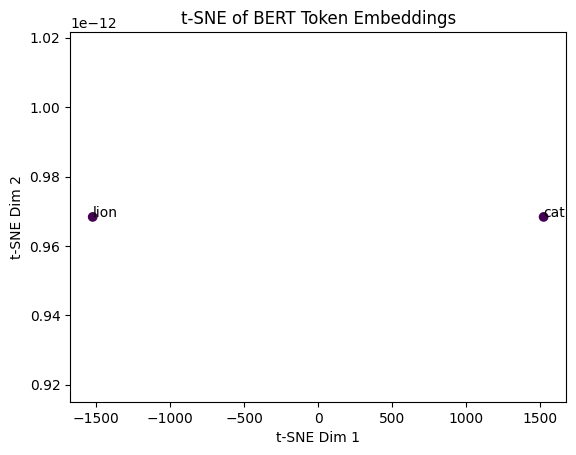

Enter a list of word pairs, separated by commas: together without
['together without']
together
without
Similarity between 'together' and 'without': 7.940562725067139
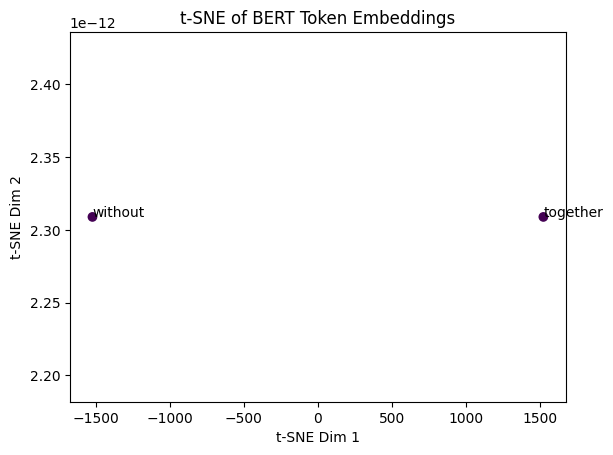


In [ ]:
import matplotlib.pyplot as plt

categories = ["Dog", "Lion", "Table"]
values = [12.76, 12.98, 13.06]

plt.bar(categories, values)

plt.xlabel("Word")
plt.ylabel("Value")
plt.title("Euclidean Distance from Cat")

plt.show()

categories = ["Dog", "Lion", "Table"]
values = [12.76, 12.98, 13.06]

plt.bar(categories, values)

plt.xlabel("Word")
plt.ylabel("Value")
plt.title("Cosine Similarity to Cat")

plt.show()

categories = ["Dog", "Lion", "Table"]
values = [6.66, 6.74, 6.76]

plt.bar(categories, values)

plt.xlabel("Word")
plt.ylabel("Value")
plt.title("Average Distance to Cat")

plt.show()

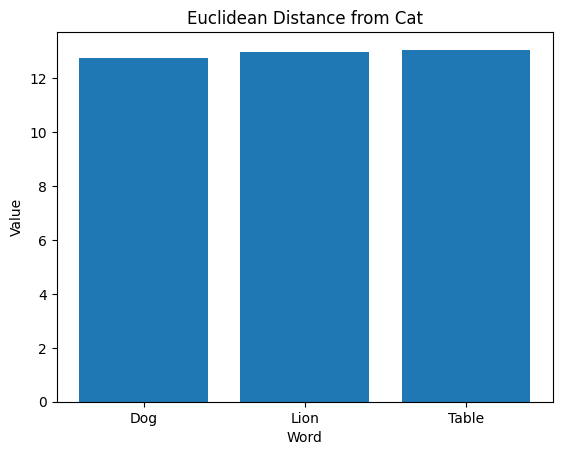

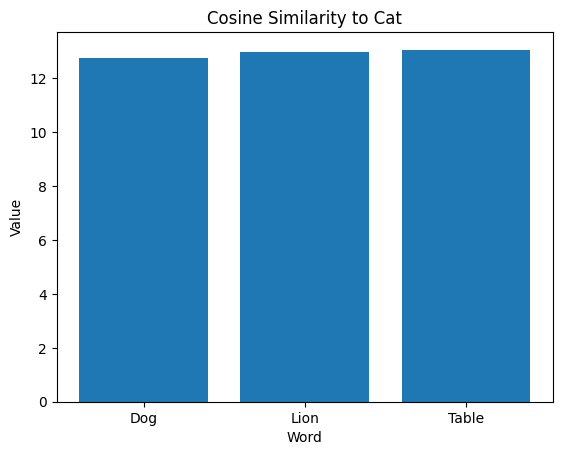

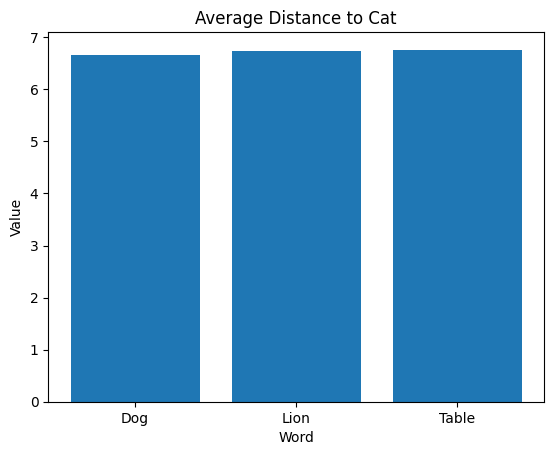